<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan7_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 7 — Pengantar Machine Learning: Regresi Linear
## Pipeline Prediksi Gaji End-to-End

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Data Science |
| **Pertemuan** | 7 — Pengantar ML: Regresi Linear |


## Langkah 1 — Generate & Eksplorasi Dataset

Dataset gaji sintetis (300 baris) dibuat dengan pola realistis: gaji dasar 3 juta, naik 2.2 juta per tahun pengalaman, naik 1.5 juta per jenjang pendidikan, bonus 4 juta untuk Jakarta, plus noise acak. `np.random.seed(42)` membuat hasil reproducible.

In [7]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)   # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
                   'kota':kota, 'gaji':gaji})

# EDA singkat
print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (300, 4)

       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


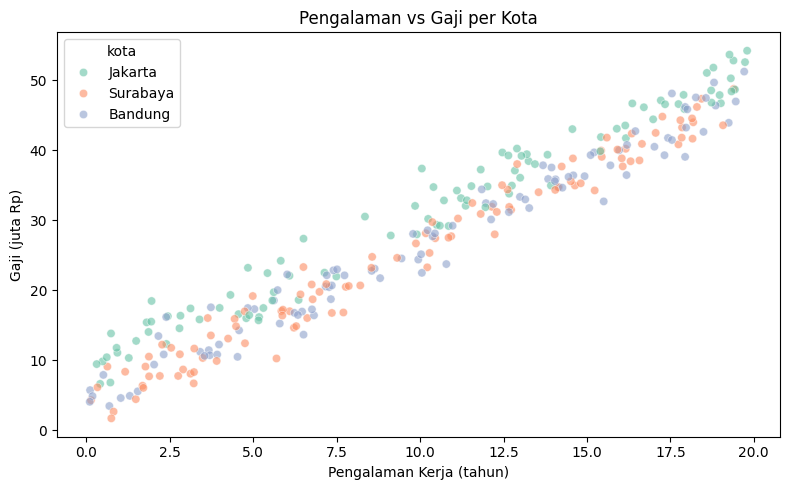

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6, ax=ax)
ax.set_title('Pengalaman vs Gaji per Kota')
ax.set_xlabel('Pengalaman Kerja (tahun)')
ax.set_ylabel('Gaji (juta Rp)')
plt.tight_layout()
plt.show()

**Interpretasi:** Dataset berisi 300 baris dengan gaji berkisar ~1.7 hingga ~54.2 juta (mean ≈ 27.4 juta). Scatter plot memperlihatkan hubungan **linear positif yang kuat** antara pengalaman dan gaji, dengan titik-titik Jakarta cenderung sedikit di atas dua kota lain pada pengalaman yang sama — sesuai bonus +4 juta dalam formula pembangkit data. Pola linear ini menjadikan Regresi Linear pilihan model yang tepat.

## Langkah 2 — Preprocessing

Kolom nominal `kota` di-One-Hot-Encode (`drop_first=True` menghindari dummy variable trap; Bandung menjadi baseline). Split 80:20 dilakukan **sebelum** scaling, lalu StandardScaler di-fit hanya pada training set — sesuai urutan anti data leakage dari Pertemuan 6.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
                    drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split (sebelum scaling!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)   # hanya transform!
print('Scaling selesai (fit hanya pada train).')

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris
Scaling selesai (fit hanya pada train).


**Interpretasi:** `kota` menjadi dua kolom biner `kota_Jakarta` dan `kota_Surabaya` (Bandung tersirat saat keduanya 0). Data terbagi 240 baris train dan 60 baris test. Test set hanya disentuh `transform()` dengan μ dan σ milik training set sehingga evaluasi nanti jujur — tidak ada informasi test yang bocor ke model.

## Langkah 3 — Latih Model & Interpretasi Koefisien

`LinearRegression` scikit-learn menghitung β optimal lewat solusi analitik **Ordinary Least Squares** (bukan gradient descent iteratif). Pola API: instantiate → fit → predict → evaluate.

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


**Interpretasi koefisien** (dalam satuan fitur terstandarisasi, sehingga besarnya bisa dibandingkan langsung antar fitur):

`pengalaman` adalah fitur **paling berpengaruh** (β ≈ 13.04 — kenaikan 1 std pengalaman ≈ +13 juta gaji), jauh di atas `kota_Jakarta` (≈ +1.84) dan `edu` (≈ +1.19). `kota_Surabaya` sedikit negatif (≈ −0.29) relatif terhadap baseline Bandung, sesuai formula data yang hanya memberi bonus ke Jakarta. Intercept β₀ ≈ 27.51 adalah prediksi gaji saat semua fitur terstandarisasi bernilai 0 (≈ rata-rata gaji train). Seluruh tanda koefisien konsisten dengan proses pembangkit data — model berhasil memulihkan pola aslinya.

## Langkah 4 — Evaluasi Model (MAE, RMSE, R²)

Tiga metrik utama regresi dihitung pada test set: MAE (rata-rata kesalahan absolut), RMSE (penalti lebih besar untuk kesalahan besar), dan R² (proporsi variasi y yang dijelaskan model).

In [11]:
from sklearn.metrics import (mean_absolute_error,
    mean_squared_error, r2_score)

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

# Verifikasi R² dengan model.score()
print(f'Verifikasi model.score(): {model.score(X_test_s, y_test):.4f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474
Verifikasi model.score(): 0.9740


**Interpretasi:**

- **MAE = 1.649 juta** — rata-rata prediksi model meleset ±1.65 juta rupiah dari gaji aktual; relatif kecil dibanding rata-rata gaji ~27 juta (error ~6%).
- **RMSE = 2.123 juta** — sedikit di atas MAE. Selisih RMSE−MAE hanya 0.474, artinya kesalahan prediksi **cukup seragam, tidak ada outlier prediksi yang ekstrem** (jika RMSE >> MAE barulah ada indikasi outlier).
- **R² = 0.974** — model menjelaskan **97.4% variasi gaji**, kategori "sangat baik". Nilai setinggi ini wajar (bukan overfitting) karena data memang dibangkitkan dari proses linear dengan noise kecil (σ=2); sisa 2.6% persis berasal dari noise acak tersebut yang memang tak bisa diprediksi.

## Langkah 5 — Visualisasi & Interpretasi

Dua plot standar evaluasi regresi: **Actual vs Predicted** (semakin rapat ke garis diagonal semakin akurat) dan **Residual Plot** (idealnya titik tersebar acak di sekitar y=0 tanpa pola).

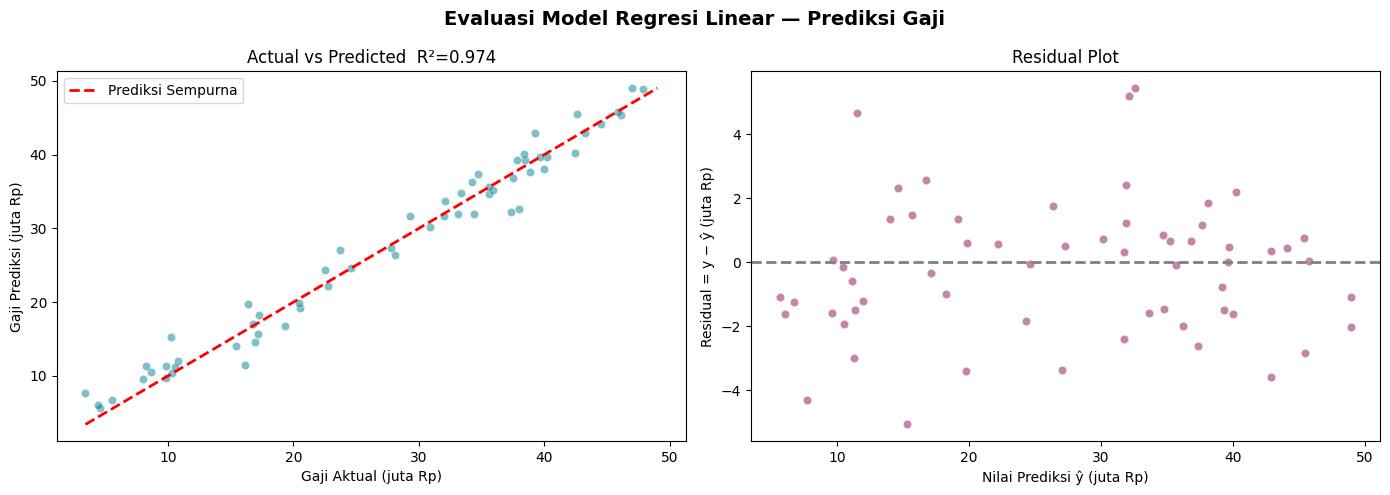

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
                color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretasi (What? / So what? / Now what?):**

**What?** Plot kiri menunjukkan 60 titik test menempel rapat pada garis diagonal "Prediksi Sempurna" di rentang gaji ~2–54 juta (R²=0.974). Plot kanan menunjukkan residual tersebar acak di pita ±5 juta di sekitar garis nol.

**So what?** Sebaran residual yang acak — tanpa pola kurva atau corong (funnel) — menandakan asumsi **linearitas dan homoscedasticity terpenuhi**: model linear memang spesifikasi yang tepat untuk data ini, dan kesalahannya murni noise. Tidak ada bias sistematis di rentang gaji rendah maupun tinggi.

**Now what?** Model layak dipakai sebagai baseline prediksi gaji. Untuk data dunia nyata, langkah lanjutan yang disarankan: validasi silang (cross-validation) untuk estimasi performa yang lebih stabil, dan uji pada data riil yang noise-nya lebih besar — bila residual mulai berpola, pertimbangkan fitur tambahan atau model non-linear (mis. Random Forest Regressor).

## Kesimpulan

Pipeline regresi linear end-to-end berhasil dibangun: dataset gaji sintetis 300 baris di-encode (OHE `kota`), displit 80:20 sebelum scaling, lalu di-scale tanpa data leakage. Model Multiple Linear Regression (OLS) memulihkan pola pembangkit data dengan akurat — `pengalaman` sebagai prediktor dominan (β≈13.04 terstandarisasi), disusul premi Jakarta dan pendidikan. Evaluasi pada test set: MAE 1.649 juta, RMSE 2.123 juta, R² 0.974 (97.4% variasi dijelaskan), dengan selisih RMSE−MAE kecil (0.474) yang menandakan tidak ada outlier prediksi. Residual plot acak mengonfirmasi asumsi linearitas terpenuhi. Sesuai rekomendasi modul, dua metrik dilaporkan: RMSE untuk benchmarking dan R² untuk komunikasi ke pemangku kepentingan non-teknis.